# RAG with LangChain —  Learning Notebook

### What is RAG?
> **RAG = Retrieve relevant facts → Augment your prompt with them → Generate an answer**

Think of it like an **open-book exam**:
- **Without RAG:** The LLM answers from memory alone (may hallucinate dates, numbers, policies)
- **With RAG:** The LLM first looks up facts in your private knowledge base, then answers

### What is LangChain?
LangChain is a framework that provides **composable building blocks** for LLM applications.
Instead of wiring every piece manually, you connect components with the `|` pipe operator:

```
retriever | format_docs | prompt | llm | output_parser
```

This is called **LCEL** (LangChain Expression Language) — we'll learn it step by step.

### What you'll build
A complete HDFC Bank AI assistant that:
1. Embeds documents and stores them in a vector database
2. Retrieves relevant facts when a user asks a question
3. Generates accurate, grounded answers
4. Remembers conversation history
5. Uses advanced retrieval techniques
6. Evaluates its own answers for accuracy
7. Acts as an autonomous agent that decides WHEN to retrieve

### Stack (all local, no API keys needed!)
| Component | Tool |
|-----------|------|
| LLM | `qwen3.5:4b` via Ollama |
| Embeddings | `qwen3-embedding:0.6b` via Ollama |
| Vector DB | ChromaDB (via LangChain wrapper) |
| Framework | LangChain LCEL |

---
**Table of Contents**
- Part 1: Embeddings with OllamaEmbeddings
- Part 2: Chunking Strategies
- Part 3: Chroma Vector Store
- Part 4: Naive RAG with LCEL (the `|` pipe operator)
- Part 5: Production RAG
- Part 6: Multi-turn Conversations
- Part 7: Advanced Retrieval
- Part 8: RAG Evaluation
- Part 9: Production Patterns
- Part 10: Agentic RAG

---
## Setup: Install Dependencies

> **What are we installing?**
> - `langchain` — core framework (LCEL, chains, agents)
> - `langchain-ollama` — connects LangChain to your local Ollama server
> - `langchain-chroma` — LangChain wrapper around ChromaDB
> - `langchain-community` — extra integrations (chat history, cross-encoders)
> - `langchain-experimental` — bleeding-edge features (SemanticChunker)
> - `chromadb` — the actual vector database running under the hood
> - `sentence-transformers` — for the re-ranking cross-encoder model
> - `scikit-learn` — PCA for visualizing embeddings

> ⚠️ **Common Mistake:** s sometimes use `langchain_community.llms.Ollama` which is deprecated.
> Always use `langchain-ollama` (the dedicated package).

In [1]:
import subprocess, sys

packages = [
    "langchain",                # Core LCEL, chains, agents
    "langchain-ollama",         # ChatOllama + OllamaEmbeddings
    "langchain-chroma",         # Chroma vector store integration
    "langchain-community",      # Extra utilities (CrossEncoder, legacy helpers)
    "langchain-experimental",   # SemanticChunker
    "langchain-text-splitters", # CharacterTextSplitter, RecursiveCharacterTextSplitter, TokenTextSplitter
    "chromadb",                 # Underlying vector DB
    "sentence-transformers",    # CrossEncoder for re-ranking
    "nltk",                     # Sentence tokenisation (used by SemanticChunker)
    "numpy",                    # Math
    "matplotlib",               # Visualisation
    "scikit-learn",             # PCA for embedding viz
    "pydantic",                 # Structured output schemas
]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "✅" if result.returncode == 0 else "❌"
    print(f"{status} {pkg}")

print("\n✅ All packages installed!")

✅ langchain
✅ langchain-ollama
✅ langchain-chroma
✅ langchain-community
✅ langchain-experimental
✅ langchain-text-splitters
✅ chromadb
✅ sentence-transformers
✅ nltk
✅ numpy
✅ matplotlib
✅ scikit-learn
✅ pydantic

✅ All packages installed!


### Configuration

We define all constants in one place so it's easy to swap models later.

> 💡 **Tip:** To get better answers, change `LLM_MODEL` to `"qwen3.5:4b"` or `"qwen3.5:4b"`.
> The 4b model gives significantly better answers.

> ⚠️ **Before running:** Make sure Ollama is running and you've pulled both models:
> ```bash
> ollama pull qwen3.5:4b
> ollama pull qwen3-embedding:0.6b
> ```

In [2]:
# All configuration in one place — change these to switch models
LLM_MODEL   = "qwen3.5:4b"       # 4b model for high quality answers
EMBED_MODEL = "qwen3-embedding:0.6b"    # qwen3-embedding 0.6b model
CHROMA_DIR  = "./chroma_lc_storage" # folder where ChromaDB stores its data on disk
COLLECTION  = "hdfc_lc"             # name of the collection inside ChromaDB

print(f"LLM    : {LLM_MODEL}")
print(f"Embed  : {EMBED_MODEL}")
print(f"Storage: {CHROMA_DIR}")

LLM    : qwen3.5:4b
Embed  : qwen3-embedding:0.6b
Storage: ./chroma_lc_storage


### Verify Ollama and Initialize LangChain Objects

🧠 **Concept: LangChain's unified `.invoke()` interface**

In raw Ollama, different tasks use different function signatures:
```python
# Raw Ollama — inconsistent APIs
ollama.generate(model="qwen3.5:4b", prompt="Hello")           # text generation
ollama.embeddings(model="qwen3-embedding:0.6b", prompt="Hello")      # embeddings
```

With LangChain, **every component** has the same `.invoke()` interface:
```python
# LangChain — unified interface
llm.invoke("Hello")                  # text generation → AIMessage
embeddings.embed_query("Hello")      # embeddings → List[float]
retriever.invoke("Hello")            # retrieval → List[Document]
```

This uniformity is what makes LCEL pipelines (`a | b | c`) possible — every component
accepts and returns in predictable formats.

> 💡 **LangChain vs Raw:**
> | Task | Raw Ollama | LangChain |
> |------|-----------|----------|
> | Generate text | `ollama.generate(model=..., prompt=...)['response']` | `llm.invoke("...").content` |
> | Get embedding | `ollama.embeddings(model=..., prompt=...)['embedding']` | `embeddings.embed_query("...")` |
> | Chain steps | Manual Python variables | `a | b | c` |

In [3]:
import ollama as _ollama_client  # only for health check — not for actual inference

# Health check: is the Ollama server process running?
try:
    _ollama_client.list()           # just lists available models — cheap operation
    print("✅ Ollama is running")
except Exception as e:
    print(f"❌ Ollama not reachable: {e}")
    print("   Start it with: ollama serve")

# Create LangChain model objects
# These are NOT making API calls yet — just configuring the connection
from langchain_ollama import ChatOllama, OllamaEmbeddings

llm = ChatOllama(
    model=LLM_MODEL,
    temperature=0.1,    # 0.0 = deterministic (good for Q&A)
                        # 1.0 = creative/varied (good for brainstorming)
)

embeddings = OllamaEmbeddings(
    model=EMBED_MODEL,  # qwen3-embedding:0.6b outputs 768-dimensional vectors
)

# Smoke test — verify both models respond
test_embed = embeddings.embed_query("hello")   # returns List[float] with 768 values
test_reply = llm.invoke("Say OK in one word")  # returns AIMessage object

# AIMessage.content extracts just the text string from the response object
print(f"✅ Embedding dim : {len(test_embed)}")             # should print 768
print(f"✅ LLM response  : {test_reply.content.strip()[:50]}")

✅ Ollama is running


/Users/suvom/anaconda3/envs/lang_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Embedding dim : 1024
✅ LLM response  : OK


---
## Part 1: Embeddings with OllamaEmbeddings

🧠 **Concept: What is an Embedding?**

An embedding converts text into a list of numbers (a **vector**) that captures **meaning**.

```
"home loan interest rate"  →  [0.12, -0.34, 0.89, ...]  (768 numbers)
"HDFC housing loan rate"   →  [0.11, -0.36, 0.87, ...]  (very similar vectors!)
"credit card rewards"      →  [0.45,  0.23, -0.12, ...]  (very different vectors!)
```

**The key insight:** Similar meaning → similar vectors → high cosine similarity score.

**Real-world analogy:** Think of embeddings like GPS coordinates for meaning.
"Delhi" and "New Delhi" would have nearby coordinates on the meaning map.
"Delhi" and "pizza" would be on opposite ends of the map.

### Two embedding methods in LangChain:
```python
embeddings.embed_query("single string")         # → List[float]  (one vector)
embeddings.embed_documents(["str1", "str2"])     # → List[List[float]]  (batch, efficient)
```

> 💡 **LangChain vs Raw:**
> ```python
> # Raw Ollama
> result = ollama.embeddings(model="qwen3-embedding:0.6b", prompt="hello")
> vector = result["embedding"]  # 768 floats
>
> # LangChain (same result, cleaner API)
> vector = embeddings.embed_query("hello")  # 768 floats directly
> ```

In [4]:
import numpy as np

# Cosine similarity: measures the angle between two vectors
# Range: -1 (opposite meaning) → 0 (unrelated) → 1 (identical meaning)
# For text embeddings in practice: > 0.85 = very similar, < 0.5 = quite different
def cosine_sim(a, b):
    a, b = np.array(a), np.array(b)
    # dot product / (magnitude of a * magnitude of b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# Four sentences — two about home loans, two questions
sentences = [
    "The interest rate on home loans is 8.5% per annum.",    # s0: home loan fact
    "HDFC Bank offers home loans starting at 8.5%.",          # s1: home loan fact (similar wording)
    "What is the EMI for a personal loan?",                   # s2: question, different topic
    "How do I apply for a credit card?",                      # s3: question, very different topic
]

# embed_documents sends ALL sentences in one batch call (more efficient than embed_query × 4)
vecs = embeddings.embed_documents(sentences)  # returns List[List[float]], shape: (4, 768)

print("Cosine similarities (expect high for similar topics, low for different topics):")
print(f"  Sent 0 vs Sent 1 (both home loan facts): {cosine_sim(vecs[0], vecs[1]):.4f}")
print(f"  Sent 0 vs Sent 2 (home loan vs personal): {cosine_sim(vecs[0], vecs[2]):.4f}")
print(f"  Sent 2 vs Sent 3 (both question style): {cosine_sim(vecs[2], vecs[3]):.4f}")
print(f"  Sent 0 vs Sent 3 (very different topics): {cosine_sim(vecs[0], vecs[3]):.4f}")

Cosine similarities (expect high for similar topics, low for different topics):
  Sent 0 vs Sent 1 (both home loan facts): 0.7059
  Sent 0 vs Sent 2 (home loan vs personal): 0.5155
  Sent 2 vs Sent 3 (both question style): 0.4521
  Sent 0 vs Sent 3 (very different topics): 0.3280


📌 **What just happened?**

The cosine similarity scores show that:
- Two sentences about **home loans** score very high (close to 1.0) — the model understands
  they mean the same thing even with different wording
- A home loan sentence vs a credit card question scores low — very different topics

This is exactly what makes **vector search** powerful: you can find relevant documents
**by meaning**, not just keyword matching.

> ⚠️ **Common Mistake:** s sometimes think vector search is just fuzzy keyword matching.
> It's NOT. The query `"housing loan charges"` would match `"home loan processing fee"`
> even though they share no exact words — because they mean the same thing.

### Visualizing Embedding Clusters with PCA

🧠 **Concept: PCA for Visualization**

Real embeddings are 1024-dimensional — impossible to plot directly.
**PCA (Principal Component Analysis)** compresses them to 2D while preserving
as much of the original structure as possible.

Think of PCA like taking a photograph of a 3D sculpture — you lose one dimension
but still capture the overall shape.

If embeddings work correctly, sentences about the same topic should **cluster together** in 2D space.

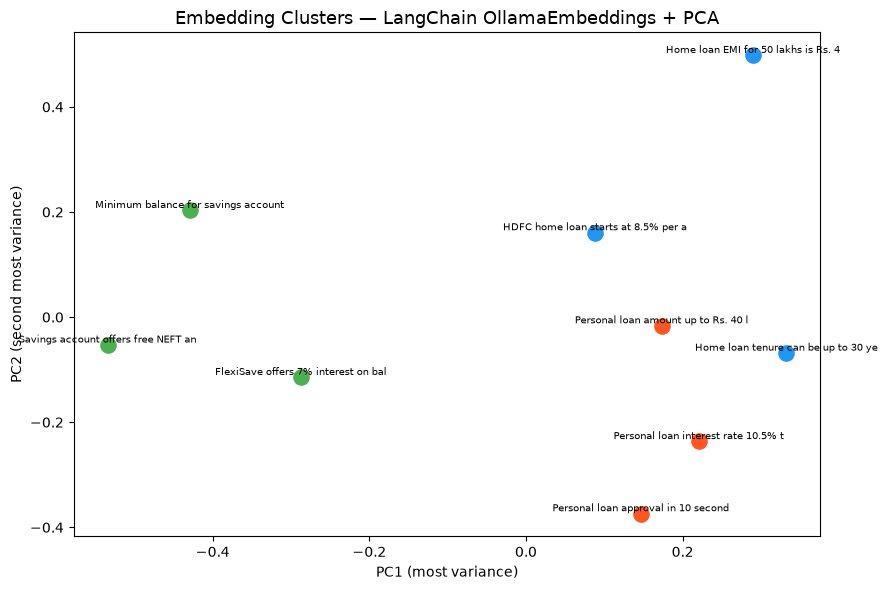

Saved: embedding_clusters_lc.png

Expected: Three visible clusters (blue=home loans, red=personal, green=savings)
This proves qwen3-embedding:0.6b understands banking domain semantics!


In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Nine banking sentences across three product categories
bank_sentences = [
    # Category 1: Home loans
    "HDFC home loan starts at 8.5% per annum",
    "Home loan tenure can be up to 30 years",
    "Home loan EMI for 50 lakhs is Rs. 43,391",
    # Category 2: Personal loans
    "Personal loan interest rate 10.5% to 24%",
    "Personal loan amount up to Rs. 40 lakhs",
    "Personal loan approval in 10 seconds",
    # Category 3: Savings accounts
    "FlexiSave offers 7% interest on balances above 1 lakh",
    "Minimum balance for savings account is Rs. 10,000",
    "Savings account offers free NEFT and RTGS",
]

# Color each category differently so clusters are visible
labels = ["Home"]*3 + ["Personal"]*3 + ["Savings"]*3
colors = ["#2196F3"]*3 + ["#FF5722"]*3 + ["#4CAF50"]*3

# Embed all 9 sentences in one batch call
vecs_all = embeddings.embed_documents(bank_sentences)  # shape: (9, 768)

# PCA: compress 768 dimensions → 2 dimensions (for plotting)
pca = PCA(n_components=2)
coords = pca.fit_transform(vecs_all)  # shape: (9, 2)

fig, ax = plt.subplots(figsize=(9, 6))
for i, (x, y) in enumerate(coords):
    ax.scatter(x, y, color=colors[i], s=120)
    ax.annotate(bank_sentences[i][:35], (x, y), fontsize=7, ha="center", va="bottom")

ax.set_title("Embedding Clusters — LangChain OllamaEmbeddings + PCA", fontsize=13)
ax.set_xlabel("PC1 (most variance)")
ax.set_ylabel("PC2 (second most variance)")
plt.tight_layout()
plt.savefig("embedding_clusters_lc.png", dpi=120)
plt.show()
print("Saved: embedding_clusters_lc.png")
print()
print("Expected: Three visible clusters (blue=home loans, red=personal, green=savings)")
print("This proves qwen3-embedding:0.6b understands banking domain semantics!")

---
## Part 2: Chunking Strategies with LangChain Text Splitters

🧠 **Concept: Why do we chunk documents?**

**The Problem:** LLMs have a **context window limit** (e.g., 4096 tokens ≈ ~3000 words).
A large PDF with 100 pages cannot fit in one prompt.

**The Solution:** Split documents into smaller "chunks", embed each chunk,
and at query time only retrieve the **relevant chunks** (not the whole document).

**The Challenge:** How you split matters a LOT:
```
❌ Bad splitting (cuts mid-sentence):
   Chunk 1: "The home loan rate is 8.5% per annum for salaried"
   Chunk 2: " employees. Processing fee is 0.50%."
   → Neither chunk has a complete, useful fact!

✅ Good splitting (at sentence/paragraph boundary):
   Chunk 1: "The home loan rate is 8.5% per annum for salaried employees."
   Chunk 2: "Processing fee is 0.50% of loan amount."
   → Each chunk is a complete, retrievable fact!
```

**Real-world analogy:** Imagine photocopying a book for study notes.
You wouldn't cut pages randomly mid-sentence — you'd cut at chapter/paragraph boundaries.

### The `chunk_overlap` parameter
```
Without overlap:  [---chunk1---][---chunk2---][---chunk3---]
With overlap:     [---chunk1---]
                          [---chunk2---]
                                  [---chunk3---]
```
Overlap ensures sentences that span a boundary appear (partially) in both adjacent chunks.
Typical rule: overlap = 10-20% of chunk_size.

### Four splitting strategies (in order of sophistication):
1. `CharacterTextSplitter` — split at one fixed character
2. `RecursiveCharacterTextSplitter` — try paragraph → sentence → word splits
3. `TokenTextSplitter` — count tokens (not characters) for LLM precision
4. `SemanticChunker` — split where the *meaning* changes (uses embeddings!)

In [6]:
from langchain_text_splitters import CharacterTextSplitter

# Sample banking document with 8 distinct facts across 3 product types
sample_text = """HDFC Bank offers a comprehensive range of home loan products.
The interest rate starts at 8.5% per annum for salaried employees.
For self-employed individuals the rate is 9.0% per annum.
Maximum loan tenure is 30 years. Processing fee is 0.50% of loan amount.
FlexiSave account offers 7% interest on balances above Rs. 1 lakh.
Minimum balance requirement is Rs. 10,000 for FlexiSave accounts.
Personal loans are available from Rs. 50,000 to Rs. 40 lakhs.
Personal loan interest rate ranges from 10.5% to 24% per annum."""

# Strategy 1: CharacterTextSplitter
# Splits ONLY on the separator you specify (here: newline)
# If a chunk is still > chunk_size after splitting on separator → it stays as-is
splitter = CharacterTextSplitter(
    chunk_size=150,    # max characters per chunk
    chunk_overlap=30,  # last 30 chars of chunk N appear at start of chunk N+1
    separator="\n",    # split at newlines first (each line = one sentence here)
)

# create_documents() takes a list of raw strings → returns List[Document]
# Each Document has .page_content (text) and .metadata (dict, empty here)
docs = splitter.create_documents([sample_text])

print(f"CharacterTextSplitter → {len(docs)} chunks")
for i, doc in enumerate(docs):
    print(f"  Chunk {i+1} ({len(doc.page_content)} chars): {doc.page_content[:80]}...")

CharacterTextSplitter → 4 chunks
  Chunk 1 (128 chars): HDFC Bank offers a comprehensive range of home loan products.
The interest rate ...
  Chunk 2 (130 chars): For self-employed individuals the rate is 9.0% per annum.
Maximum loan tenure is...
  Chunk 3 (132 chars): FlexiSave account offers 7% interest on balances above Rs. 1 lakh.
Minimum balan...
  Chunk 4 (125 chars): Personal loans are available from Rs. 50,000 to Rs. 40 lakhs.
Personal loan inte...


In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Strategy 2: RecursiveCharacterTextSplitter — the recommended default
# Tries separators in priority order: "\n\n" → "\n" → " " → ""
# This preserves paragraph structure before falling back to sentence/word splits
#
# Analogy: a smart editor who tries to cut at chapter breaks first,
# then paragraph breaks, then sentence breaks — always the most natural split
rec_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=40,
    # default separators: ["\n\n", "\n", " ", ""]
    # You can customize: separators=["\n\n", "\n", ". ", " ", ""]
)

rec_docs = rec_splitter.create_documents([sample_text])
print(f"RecursiveCharacterTextSplitter → {len(rec_docs)} chunks")
for i, doc in enumerate(rec_docs):
    print(f"  Chunk {i+1} ({len(doc.page_content)} chars): {doc.page_content[:90]}...")

print()
print("Key difference from CharacterTextSplitter:")
print("  Character: splits ONLY on the one separator you give")
print("  Recursive: tries multiple separators in order (smarter, more natural)")

RecursiveCharacterTextSplitter → 3 chunks
  Chunk 1 (186 chars): HDFC Bank offers a comprehensive range of home loan products.
The interest rate starts at ...
  Chunk 2 (139 chars): Maximum loan tenure is 30 years. Processing fee is 0.50% of loan amount.
FlexiSave account...
  Chunk 3 (191 chars): Minimum balance requirement is Rs. 10,000 for FlexiSave accounts.
Personal loans are avail...

Key difference from CharacterTextSplitter:
  Character: splits ONLY on the one separator you give
  Recursive: tries multiple separators in order (smarter, more natural)


In [8]:
from langchain_text_splitters import TokenTextSplitter

# Strategy 3: TokenTextSplitter
# LLMs count TOKENS, not characters. A token ≈ 0.75 words in English.
# "HDFC" = 1 token. "antidisestablishmentarianism" = 5 tokens.
# Use this when you need precise control over how much context goes to the LLM.
#
# ⚠️ Common Mistake: CharacterTextSplitter(chunk_size=4000) thinking
# "that's under the 4096 token limit" — WRONG! 4000 chars ≈ 1000 tokens,
# but in dense text with long words, 4000 chars could be 2000+ tokens.
tok_splitter = TokenTextSplitter(
    chunk_size=50,      # 50 TOKENS (not characters!)
    chunk_overlap=10,   # 10-token overlap
    # Uses tiktoken (BPE tokenizer) under the hood for counting
)

tok_docs = tok_splitter.create_documents([sample_text])
print(f"TokenTextSplitter → {len(tok_docs)} chunks (by token count, not characters)")
for i, doc in enumerate(tok_docs):
    char_count = len(doc.page_content)
    # Notice: character count varies even though token count is fixed at ~50
    print(f"  Chunk {i+1} (~50 tokens, {char_count} chars): {doc.page_content[:90]}...")

TokenTextSplitter → 4 chunks (by token count, not characters)
  Chunk 1 (~50 tokens, 194 chars): HDFC Bank offers a comprehensive range of home loan products.
The interest rate starts at ...
  Chunk 2 (~50 tokens, 187 chars):  9.0% per annum.
Maximum loan tenure is 30 years. Processing fee is 0.50% of loan amount.
...
  Chunk 3 (~50 tokens, 186 chars):  Rs. 1 lakh.
Minimum balance requirement is Rs. 10,000 for FlexiSave accounts.
Personal lo...
  Chunk 4 (~50 tokens, 63 chars): Personal loan interest rate ranges from 10.5% to 24% per annum....


In [9]:
from langchain_experimental.text_splitter import SemanticChunker

# Strategy 4: SemanticChunker — the most intelligent splitter
# Uses embeddings to detect where the TOPIC CHANGES in the text.
#
# How it works:
# 1. Split text into sentences (using nltk)
# 2. Embed each sentence
# 3. Compute cosine similarity between adjacent sentences
# 4. Where similarity DROPS SHARPLY = topic change = chunk boundary
#
# breakpoint_threshold_type="percentile" + amount=85:
# → Only split at places where the drop is in the top 15% of all drops
# → Prevents over-splitting; only breaks at MAJOR topic shifts
sem_splitter = SemanticChunker(
    embeddings,                              # uses our OllamaEmbeddings object
    breakpoint_threshold_type="percentile",  # strategy: look at distribution of drops
    breakpoint_threshold_amount=85,          # split at top 15% of similarity drops
)

# Note: takes longer than other splitters — it embeds every sentence!
sem_docs = sem_splitter.create_documents([sample_text])
print(f"SemanticChunker → {len(sem_docs)} chunks (split where meaning changes)")
for i, doc in enumerate(sem_docs):
    print(f"  Chunk {i+1} ({len(doc.page_content)} chars): {doc.page_content[:100]}...")

print()
print("Why SemanticChunker produces the best chunks:")
print("  Other splitters: split at character/token counts → may cut mid-sentence")
print("  SemanticChunker: split where content TOPIC shifts → coherent, self-contained chunks")

/var/folders/hx/b4sh2ccn5rg70j3_06lrkcjc0000gn/T/ipykernel_23158/3647813616.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.text_splitter import SemanticChunker


SemanticChunker → 3 chunks (split where meaning changes)
  Chunk 1 (219 chars): HDFC Bank offers a comprehensive range of home loan products. The interest rate starts at 8.5% per a...
  Chunk 2 (210 chars): Processing fee is 0.50% of loan amount. FlexiSave account offers 7% interest on balances above Rs. 1...
  Chunk 3 (87 chars): 50,000 to Rs. 40 lakhs. Personal loan interest rate ranges from 10.5% to 24% per annum....

Why SemanticChunker produces the best chunks:
  Other splitters: split at character/token counts → may cut mid-sentence
  SemanticChunker: split where content TOPIC shifts → coherent, self-contained chunks


In [10]:
# Side-by-side comparison of all four strategies
strategies = {
    "CharacterTextSplitter"          : len(docs),
    "RecursiveCharacterTextSplitter" : len(rec_docs),
    "TokenTextSplitter"              : len(tok_docs),
    "SemanticChunker"                : len(sem_docs),
}

print(f"{'Strategy':<40} {'Chunks':>6}")
print("-" * 48)
for name, n in strategies.items():
    print(f"  {name:<38} {n:>6}")

print()
print("Rule of thumb for production:")
print("  RecursiveCharacterTextSplitter → default choice (fast, good quality)")
print("  TokenTextSplitter              → when LLM context window is tight")
print("  SemanticChunker                → when retrieval quality matters most (slower)")

Strategy                                 Chunks
------------------------------------------------
  CharacterTextSplitter                       4
  RecursiveCharacterTextSplitter              3
  TokenTextSplitter                           4
  SemanticChunker                             3

Rule of thumb for production:
  RecursiveCharacterTextSplitter → default choice (fast, good quality)
  TokenTextSplitter              → when LLM context window is tight
  SemanticChunker                → when retrieval quality matters most (slower)


---
## Part 3: Chroma Vector Store via LangChain

🧠 **Concept: What does a Vector Store do?**

A vector store is a database optimized for similarity search:
1. **Store:** Accept documents + auto-embed them
2. **Index:** Build a fast nearest-neighbor index (HNSW algorithm)
3. **Retrieve:** Given a query, find the k most similar documents by meaning

**Analogy:** Like a librarian who has memorized the "essence" of every book.
You say "I'm interested in home loan rates" and they instantly know which shelf to check
— not by reading titles, but by understanding meaning.

```
           VECTOR STORE (ChromaDB)
          ┌───────────────────────────────────────┐
  Doc 1   │  "home loan 8.5%..."  → [0.1, 0.8, ...]  │
  Doc 2   │  "FlexiSave 7%..."    → [0.3, 0.2, ...]  │
  Doc 3   │  "personal loan..."   → [0.7, 0.1, ...]  │
          └───────────────────────────────────────┘
                            ↑
  Query: "home loan rate"  → [0.12, 0.79, ...]  (similar to Doc 1 vector)
  ChromaDB finds nearest  → Doc 1 wins! ✅
```

> 💡 **LangChain vs Raw ChromaDB:**
> ```python
> # Raw ChromaDB (verbose — 6 lines of boilerplate)
> import chromadb
> from chromadb.utils.embedding_functions import OllamaEmbeddingFunction
> client = chromadb.PersistentClient(path=CHROMA_DIR)
> ef = OllamaEmbeddingFunction(url="http://localhost:11434/api/embeddings", model_name=EMBED_MODEL)
> collection = client.get_or_create_collection("hdfc", embedding_function=ef)
>
> # LangChain (same result, 1 line)
> vectorstore = Chroma(collection_name="hdfc", embedding_function=embeddings, persist_directory=CHROMA_DIR)
> ```

In [11]:
import shutil, os
from langchain_chroma import Chroma   # LangChain's Chroma wrapper

# Fresh start: wipe any existing storage so we begin clean each run
if os.path.exists(CHROMA_DIR):
    shutil.rmtree(CHROMA_DIR)    # delete the entire folder and its contents
    print(f"Deleted existing storage at {CHROMA_DIR}")

# Create the vector store (empty — we add documents next)
vectorstore = Chroma(
    collection_name=COLLECTION,        # name of the collection inside ChromaDB
    embedding_function=embeddings,     # our OllamaEmbeddings — used for queries too
    persist_directory=CHROMA_DIR,      # where to save data on disk (survives restarts)
)

print(f"✅ Chroma vector store created at {CHROMA_DIR}")
print(f"   Collection: {COLLECTION}")
print()
print("What LangChain does under the hood:")
print("  1. Creates a chromadb.PersistentClient pointing to CHROMA_DIR")
print("  2. Creates (or opens) a collection named COLLECTION")
print("  3. Wraps your embeddings object so ChromaDB can call it automatically")
print("  4. All embed calls go through qwen3-embedding:0.6b via Ollama")

✅ Chroma vector store created at ./chroma_lc_storage
   Collection: hdfc_lc

What LangChain does under the hood:
  1. Creates a chromadb.PersistentClient pointing to CHROMA_DIR
  2. Creates (or opens) a collection named COLLECTION
  3. Wraps your embeddings object so ChromaDB can call it automatically
  4. All embed calls go through qwen3-embedding:0.6b via Ollama


### Adding Documents to the Vector Store

In LangChain, documents are wrapped in `Document` objects with two fields:
- `page_content` — the actual text (what gets **embedded and retrieved**)
- `metadata` — a dictionary of extra info (source, category, date, etc.) — **not embedded**

> ⚠️ **Common Mistake:** Storing all info in `page_content` instead of using `metadata`.
> Keep retrieval text in `page_content` and filter/display info in `metadata`.
>
> ✅ Good: `Document(page_content="EMI is Rs. 43,391", metadata={"category": "home_loan"})`
> ❌ Bad: `Document(page_content="category=home_loan, EMI is Rs. 43,391")` — dilutes the embedding!

In [12]:
from langchain_core.documents import Document

# 15 documents across 5 categories — our HDFC Bank knowledge base
documents = [
    # Home loans
    Document(page_content="HDFC home loan interest rate starts at 8.5% per annum. The tenure can be up to 30 years. Processing fee is 0.50% of loan amount.", metadata={"source":"hdfc_loans","category":"home_loan"}),
    Document(page_content="For a home loan of Rs. 50 lakhs, the EMI at 8.5% for 20 years is approximately Rs. 43,391 per month.", metadata={"source":"hdfc_loans","category":"home_loan"}),
    Document(page_content="Documents required for home loan: PAN card, Aadhaar, 6-month salary slips, 2-year ITR, bank statements.", metadata={"source":"hdfc_loans","category":"home_loan"}),
    Document(page_content="Home loan prepayment is free for floating rate loans. Fixed rate loans have 2% prepayment charge.", metadata={"source":"hdfc_loans","category":"home_loan"}),
    # Savings accounts
    Document(page_content="FlexiSave account offers 7% interest per annum on balances above Rs. 1 lakh. Standard rate is 3.5% below 1 lakh.", metadata={"source":"hdfc_savings","category":"savings"}),
    Document(page_content="Minimum balance requirement for FlexiSave is Rs. 10,000. Non-maintenance fee is Rs. 600 per quarter.", metadata={"source":"hdfc_savings","category":"savings"}),
    Document(page_content="HDFC savings account holders get free NEFT, RTGS, and unlimited ATM transactions at HDFC ATMs.", metadata={"source":"hdfc_savings","category":"savings"}),
    # Personal loans
    Document(page_content="HDFC personal loan interest rate ranges from 10.5% to 24% per annum based on credit score.", metadata={"source":"hdfc_loans","category":"personal_loan"}),
    Document(page_content="Personal loan amount ranges from Rs. 50,000 to Rs. 40 lakhs. Tenure 1 to 5 years. Approval in 10 seconds for pre-approved customers.", metadata={"source":"hdfc_loans","category":"personal_loan"}),
    Document(page_content="Foreclosure of personal loan is allowed after 12 EMIs with 2-4% foreclosure charges.", metadata={"source":"hdfc_loans","category":"personal_loan"}),
    # Credit cards
    Document(page_content="HDFC Regalia credit card offers 4 reward points per Rs. 150 spent. Annual fee Rs. 2,500 waived on Rs. 3 lakh spend.", metadata={"source":"hdfc_cards","category":"credit_card"}),
    Document(page_content="HDFC MoneyBack credit card offers 2 reward points per Rs. 150. Annual fee Rs. 500 waived on Rs. 50,000 spend.", metadata={"source":"hdfc_cards","category":"credit_card"}),
    Document(page_content="Credit card bill payment by 5th of each month avoids interest. Late payment fee Rs. 100 to Rs. 1,300.", metadata={"source":"hdfc_cards","category":"credit_card"}),
    # Fixed deposits
    Document(page_content="HDFC FD rates: 7.10% for 1 year, 7.25% for 2 years, 7.40% for 3 years. Senior citizens get 0.50% extra.", metadata={"source":"hdfc_deposits","category":"fd"}),
    Document(page_content="Minimum FD amount is Rs. 5,000. Maximum tenure is 10 years. Premature withdrawal penalty is 1%.", metadata={"source":"hdfc_deposits","category":"fd"}),
]

# add_documents() embeds each document and stores (vector, text, metadata) in ChromaDB
# LangChain handles batching the embed calls automatically
ids = vectorstore.add_documents(documents)
print(f"✅ Added {len(documents)} documents to Chroma")
print(f"   IDs (first 3): {ids[:3]}")
print()
print("For each document, LangChain:")
print("  1. Calls embeddings.embed_documents([page_content])")
print("  2. Gets a 768-dim vector from qwen3-embedding:0.6b")
print("  3. Stores {vector, page_content, metadata, id} in ChromaDB")
print("  4. ChromaDB builds HNSW index for fast nearest-neighbor lookup")

✅ Added 15 documents to Chroma
   IDs (first 3): ['77ffc28f-4be1-4365-86c4-4f238d4561b5', '8b9f5a5e-3230-40de-9b97-a572ad68e66b', 'f1a20a74-f806-477f-95d7-beb5a65ecc12']

For each document, LangChain:
  1. Calls embeddings.embed_documents([page_content])
  2. Gets a 768-dim vector from qwen3-embedding:0.6b
  3. Stores {vector, page_content, metadata, id} in ChromaDB
  4. ChromaDB builds HNSW index for fast nearest-neighbor lookup


In [13]:
# LangChain's Chroma exposes three search methods — each has a different use case

print("=== Method 1: similarity_search() — returns Document objects ===")
# Most common — use when you just need the documents
results = vectorstore.similarity_search(
    "home loan interest rate",  # LangChain embeds this automatically
    k=3                          # return top-3 most similar documents
)
for i, doc in enumerate(results, 1):
    print(f"  [{i}] ({doc.metadata['category']}) {doc.page_content[:80]}...")

print()
print("=== Method 2: similarity_search_with_score() — includes distance ===")
# Use when you want to filter by a similarity threshold
# Note: ChromaDB returns L2 DISTANCE (lower = more similar), not cosine similarity!
results_scores = vectorstore.similarity_search_with_score("FlexiSave minimum balance", k=2)
for doc, score in results_scores:
    print(f"  Distance {score:.4f} (lower=more similar): {doc.page_content[:80]}...")

print()
print("=== Method 3: as_retriever() — the standard way for LCEL chains ===")
# Returns a Retriever OBJECT with .invoke() — plugs directly into LCEL pipelines
# This is what we'll use in all our chains going forward
retriever = vectorstore.as_retriever(
    search_type="similarity",      # can also be "mmr" for diversity
    search_kwargs={"k": 3},        # return top-3
)
retrieved = retriever.invoke("personal loan foreclosure")
print(f"  Retrieved {len(retrieved)} docs for 'personal loan foreclosure'")
print(f"  Top result: {retrieved[0].page_content[:100]}...")
print()
print("Why use as_retriever() vs similarity_search() directly?")
print("  as_retriever() returns a Retriever OBJECT → works in LCEL chains with |")
print("  similarity_search() is just a function call → can't chain with |")

=== Method 1: similarity_search() — returns Document objects ===
  [1] (home_loan) HDFC home loan interest rate starts at 8.5% per annum. The tenure can be up to 3...
  [2] (home_loan) Home loan prepayment is free for floating rate loans. Fixed rate loans have 2% p...
  [3] (home_loan) For a home loan of Rs. 50 lakhs, the EMI at 8.5% for 20 years is approximately R...

=== Method 2: similarity_search_with_score() — includes distance ===
  Distance 0.5060 (lower=more similar): Minimum balance requirement for FlexiSave is Rs. 10,000. Non-maintenance fee is ...
  Distance 0.5687 (lower=more similar): FlexiSave account offers 7% interest per annum on balances above Rs. 1 lakh. Sta...

=== Method 3: as_retriever() — the standard way for LCEL chains ===
  Retrieved 3 docs for 'personal loan foreclosure'
  Top result: Foreclosure of personal loan is allowed after 12 EMIs with 2-4% foreclosure charges....

Why use as_retriever() vs similarity_search() directly?
  as_retriever() returns a Retri

---
## Part 4: Naive RAG with LCEL (The `|` Pipe Operator)

🧠 **Concept: LCEL — LangChain Expression Language**

LCEL lets you compose components with `|` like **Unix pipes**:
```bash
# Unix: output of cat → input of grep → input of wc
cat file.txt | grep "error" | wc -l
```
```python
# LCEL: output of each step becomes input of the next
retriever | format_docs | prompt | llm | StrOutputParser()
```

**ASCII diagram of our RAG chain:**
```
User Query: "What is the home loan rate?"
     │
     ▼
┌──────────────────────────────────────────────┐
│  {                                           │
│    "context": retriever | format_docs,       │  ← retriever gets 3 docs,
│    "question": RunnablePassthrough()         │    format_docs joins them into string
│  }                                           │  ← question string passes unchanged
└──────────────────────────────────────────────┘
     │
     ▼
┌──────────────────────────────────────────────┐
│  ChatPromptTemplate                          │  ← fills {context} and {question}
│  "Use context below to answer..."            │    placeholders in template
└──────────────────────────────────────────────┘
     │
     ▼
┌──────────────────────────────────────────────┐
│  ChatOllama (qwen3.5:4b)                   │  ← calls Ollama with filled prompt
│  → AIMessage(content="8.5% per annum...")    │    returns AIMessage object
└──────────────────────────────────────────────┘
     │
     ▼
┌──────────────────────────────────────────────┐
│  StrOutputParser()                           │  ← extracts .content string from AIMessage
└──────────────────────────────────────────────┘
     │
     ▼
"The home loan rate is 8.5% per annum."
```

**Key LCEL components:**
- `RunnablePassthrough()` — passes input unchanged (identity function)
- `StrOutputParser()` — converts `AIMessage(content=...)` to plain `str`
- The dict `{"context": ..., "question": ...}` — splits input into two parallel streams

In [14]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Step 1: Prompt template with two placeholders: {context} and {question}
# ChatPromptTemplate.from_template() creates a single human message prompt
NAIVE_PROMPT = ChatPromptTemplate.from_template("""Use the context below to answer the question.
Context:
{context}

Question: {question}
Answer:""")

# Step 2: Helper to convert List[Document] → one string
# The | operator can only pass one value between steps, so we join all docs
def format_docs(docs):
    """
    Input:  [Document("Rate is 8.5%"), Document("Tenure 30 years")]
    Output: "Rate is 8.5%\n\nTenure 30 years"
    Double newline separates chunks visually so the LLM can distinguish them.
    """
    return "\n\n".join(doc.page_content for doc in docs)

# Step 3: Build the LCEL chain
# The dict creates TWO parallel pathways that merge into one dict:
#   "context" path:  query → retriever → [doc1, doc2] → format_docs → "doc1\n\ndoc2"
#   "question" path: query → RunnablePassthrough() → same query string
# Then the dict is passed to NAIVE_PROMPT which fills {context} and {question}
naive_rag_chain = (
    {
        "context" : retriever | format_docs,   # retriever.invoke(q) → format_docs(docs)
        "question": RunnablePassthrough(),      # passes query through unchanged
    }
    | NAIVE_PROMPT       # fills template → ChatPromptValue
    | llm                # ChatPromptValue → AIMessage(content="...")
    | StrOutputParser()  # AIMessage → plain string
)

# Step 4: Run the chain — just pass the question string!
q = "What is the interest rate for HDFC home loans?"
answer = naive_rag_chain.invoke(q)
print(f"Q: {q}")
print(f"A: {answer}")
print()
print("LCEL breakdown of what happened:")
print("  1. query → retriever → 3 relevant Document objects")
print("  2. 3 Documents → format_docs → one big context string")
print("  3. query → RunnablePassthrough → same query string")
print("  4. {context, question} → NAIVE_PROMPT → filled prompt")
print("  5. prompt → llm → AIMessage(content='8.5% per annum...')")
print("  6. AIMessage → StrOutputParser → '8.5% per annum...' (plain string)")

Q: What is the interest rate for HDFC home loans?
A: Based on the context provided, the HDFC home loan interest rate **starts at 8.5% per annum**.

LCEL breakdown of what happened:
  1. query → retriever → 3 relevant Document objects
  2. 3 Documents → format_docs → one big context string
  3. query → RunnablePassthrough → same query string
  4. {context, question} → NAIVE_PROMPT → filled prompt
  5. prompt → llm → AIMessage(content='8.5% per annum...')
  6. AIMessage → StrOutputParser → '8.5% per annum...' (plain string)


📌 **What just happened?**

You built a complete RAG pipeline in ~10 lines using the `|` operator!

> ⚠️ **Common Mistake 1:** Calling `naive_rag_chain.invoke({"question": q})` instead of
> `naive_rag_chain.invoke(q)`. Since the chain starts with a routing dict, pass the raw string!

> ⚠️ **Common Mistake 2:** Forgetting `StrOutputParser()` at the end. Without it,
> the chain returns an `AIMessage` object — you'd need `.content` to get the string.

**Limitation of Naive RAG:** The chain doesn't tell you WHICH documents it used.
For production, we need citations → see Part 5.

---
## Part 5: Production RAG (create_retrieval_chain + create_stuff_documents_chain)

🧠 **Concept: Why upgrade from Naive RAG?**

Our naive chain has two limitations:
1. **No citations** — we don't know which documents were used to generate the answer
2. **No role separation** — we mixed system instructions and user question in one template

LangChain's high-level helpers solve both:

```python
# Naive RAG — just the answer
naive_rag_chain.invoke("question")  →  "answer string"

# Production RAG — structured output with sources
prod_rag_chain.invoke({"input": "question"})  →  {
    "input":   "question",
    "context": [doc1, doc2, doc3],   # ← actual Document objects used!
    "answer":  "answer string"
}
```

**What does "stuff" mean in `create_stuff_documents_chain`?**

"Stuff" is a LangChain strategy name meaning **"stuff all retrieved documents into the prompt
at once"**. This is the right choice when you have a small number of chunks (< 10).

Other strategies (for very long documents):
- `map_reduce` — process each chunk separately, then combine summaries
- `refine` — process chunks one by one, refining the answer each time

For our banking Q&A with 3-5 retrieved chunks, `stuff` is always the right choice.

In [15]:
from langchain_classic.chains import LLMChain

from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

# Step 1: System prompt with {context} and {input} placeholders
# The system message sets the persona and constraints
# {context} will be automatically filled with retrieved documents
SYSTEM_PROMPT = """You are an HDFC Bank assistant.
Answer ONLY using the context provided below. Be factual and concise.
If the answer is not in the context, say: "I don't have that information. Call 1800-202-6161."
Do not make up numbers.

Context:
{context}"""

# from_messages() creates a chat-style prompt with system + human roles
# This maps to how models expect structured conversations
prod_prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),   # system role: instructions + context placeholder
    ("human", "{input}"),         # human role: the user's actual question
])

# Step 2: create_stuff_documents_chain
# Takes (llm, prompt) → returns a chain that:
#   - accepts retrieved documents and formats them into {context}
#   - accepts the user question as {input}
#   - calls the LLM and returns the answer
combine_docs_chain = create_stuff_documents_chain(llm, prod_prompt)

# Step 3: create_retrieval_chain
# Wraps combine_docs_chain with automatic retrieval
# Input:  {"input": "question string"}
# Output: {"input": ..., "context": [docs], "answer": "..."}  ← structured!
prod_rag_chain = create_retrieval_chain(retriever, combine_docs_chain)

# Step 4: Run — notice we pass a dict with "input" key (not a raw string)
result = prod_rag_chain.invoke({"input": "What are the charges for home loan prepayment?"})

print(f"Q: {result['input']}")
print(f"A: {result['answer']}")
print()
print("Sources (actual Document objects used):")
for doc in result["context"]:
    print(f"  • [{doc.metadata['source']}] {doc.page_content[:70]}...")

Q: What are the charges for home loan prepayment?
A: Home loan prepayment is free for floating rate loans, while fixed rate loans have a 2% prepayment charge.

Sources (actual Document objects used):
  • [hdfc_loans] Home loan prepayment is free for floating rate loans. Fixed rate loans...
  • [hdfc_loans] Foreclosure of personal loan is allowed after 12 EMIs with 2-4% forecl...
  • [hdfc_cards] Credit card bill payment by 5th of each month avoids interest. Late pa...


---
## Part 6: Multi-Turn Conversations with RunnableWithMessageHistory

🧠 **Concept: The Co-reference Problem**

Consider this conversation:
```
User: "What is the home loan interest rate?"
Bot:  "It's 8.5% per annum."
User: "What documents do I need for IT?"    ← 'IT' = home loan, but the system doesn't know!
```

A naive RAG system embeds "What documents do I need for IT?" → poor retrieval.

**Solution:** Before retrieving, rewrite the question using conversation history:
```
"What documents do I need for IT?" + history → "What documents for a home loan?"
```

**Session concept:** Each user gets an isolated conversation history.
`RunnableWithMessageHistory` manages this automatically via `session_id`.

```
session_store = {
    "user_123": InMemoryChatMessageHistory([           # User A's history
        HumanMessage("home loan rate?"),
        AIMessage("8.5% per annum"),
        HumanMessage("documents for it?"),
    ]),
    "user_456": InMemoryChatMessageHistory([...]),     # User B's separate history
}
```

> ⚠️ **Common Mistake:** Using the same `session_id` for different users — they'll see
> each other's conversation history! Always generate a unique ID per user session.

In [16]:
from langchain_classic.chains import create_history_aware_retriever
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory

# Step 1: History-aware retriever
# This is the key magic: takes (current question + chat history)
# and rewrites the question to be self-contained BEFORE retrieval
contextualize_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Given the chat history and latest user question, "
     "rewrite it as a self-contained standalone question. "
     "Return ONLY the rewritten question."),
    MessagesPlaceholder("chat_history"),  # LangChain injects conversation history here
    ("human", "{input}"),                 # the current ambiguous question
])

# create_history_aware_retriever: LLM rewrites question → retrieves with rewritten query
history_aware_retriever = create_history_aware_retriever(
    llm,                    # used to rewrite the ambiguous question
    retriever,              # base retriever to search ChromaDB
    contextualize_prompt,   # the question-rewriting prompt
)

# Step 2: QA chain that also sees conversation history
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an HDFC Bank assistant.
Answer ONLY using the context provided. Be concise.
If the answer is not in the context, say: "I don't have that information."

{context}"""),
    MessagesPlaceholder("chat_history"),  # previous turns give the LLM context
    ("human", "{input}"),
])

qa_chain = create_stuff_documents_chain(llm, qa_prompt)

# Step 3: Full conversational RAG chain
conv_rag_chain = create_retrieval_chain(history_aware_retriever, qa_chain)

# Step 4: Wrap with automatic history management
# session_store maps session_id → InMemoryChatMessageHistory object
session_store = {}

def get_session_history(session_id: str) -> InMemoryChatMessageHistory:
    """Return the existing history for this session, or create a new empty one."""
    if session_id not in session_store:
        session_store[session_id] = InMemoryChatMessageHistory()  # empty history for new sessions
    return session_store[session_id]

# RunnableWithMessageHistory wraps the chain:
# - BEFORE invoke: loads history from session_store for this session_id
# - AFTER invoke: saves new Q+A to session_store automatically
conversational_chain = RunnableWithMessageHistory(
    conv_rag_chain,
    get_session_history,
    input_messages_key="input",            # key containing the user's question
    history_messages_key="chat_history",   # which placeholder to fill with history
    output_messages_key="answer",          # key containing the answer to save
)

# config identifies which session (user) this belongs to
config = {"configurable": {"session_id": "user_123"}}

print("Turn 1:")
r1 = conversational_chain.invoke({"input": "What is the home loan interest rate?"}, config=config)
print(f"  Q: What is the home loan interest rate?")
print(f"  A: {r1['answer']}")

print()
print("Turn 2: 'it' refers to home loan — the chain must figure this out!")
r2 = conversational_chain.invoke({"input": "What documents do I need for it?"}, config=config)
print(f"  Q: What documents do I need for it?")
print(f"  A: {r2['answer']}")
# Behind the scenes: rewriter sees Turn 1 + "What documents for it?" → "home loan documents"

print()
print("Turn 3:")
r3 = conversational_chain.invoke({"input": "What is the processing fee?"}, config=config)
print(f"  Q: What is the processing fee?")
print(f"  A: {r3['answer']}")

Turn 1:


/Users/suvom/anaconda3/envs/lang_venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


  Q: What is the home loan interest rate?
  A: HDFC home loan interest rate starts at 8.5% per annum.

Turn 2: 'it' refers to home loan — the chain must figure this out!
  Q: What documents do I need for it?
  A: Documents required for home loan: PAN card, Aadhaar, 6-month salary slips, 2-year ITR, bank statements.

Turn 3:
  Q: What is the processing fee?
  A: HDFC home loan processing fee is 0.50% of the loan amount.


---
## Part 7: Advanced Retrieval Techniques

### Why is Basic Retrieval Not Enough?

Standard single-query retrieval fails in predictable ways. Let's see each failure mode and the technique that fixes it:

```
FAILURE → TECHNIQUE MAP
========================

Problem 1: SHORT / VAGUE QUERY
  User types: "EMI?"
  Embedding of "EMI?" is weak → retrieves random docs
  ──────────────────────────────────────────────────────
  Fix: QUERY REWRITING (Technique 1)
  LLM expands "EMI?" → "What is the monthly EMI for HDFC home loan at 8.5%?"
  Strong, specific embedding → precise retrieval

Problem 2: SINGLE PHRASING MISSES SYNONYMS
  User types: "mortgage monthly payment"
  DB has: "home loan EMI" — different words, same meaning
  Single embedding may miss it
  ──────────────────────────────────────────────────────
  Fix: MULTI-QUERY RETRIEVAL (Technique 3)
  Generate 3 phrasings → retrieve for each → merge
  "mortgage monthly payment" + "home loan EMI" + "housing instalment" → better coverage

Problem 3: QUESTION ≠ DOCUMENT STYLE
  User types: "What is the home loan rate?"  (interrogative, short)
  Documents:  "Home loan starts at 8.5% per annum." (declarative, longer)
  Different embedding distributions → imperfect match
  ──────────────────────────────────────────────────────
  Fix: HyDE (Technique 2)
  Generate a fake answer → "Home loan rate is around 8.5% per annum..."
  Embed the fake answer (same style as real docs) → much better match

Problem 4: BI-ENCODER RANKS WRONG DOCS FIRST
  Embedding model encodes query and doc SEPARATELY → approximate scores
  "loan documents required" might rank credit card docs above home loan docs
  ──────────────────────────────────────────────────────
  Fix: RE-RANKING / ContextualCompressionRetriever (Technique 4)
  Cross-encoder reads query + doc TOGETHER → precise relevance score
  Re-ranks top-20 bi-encoder results → returns true top-3

Problem 5: SMALL CHUNKS LACK CONTEXT
  Index small chunks (precise retrieval) but LLM only sees 1 sentence → incomplete answer
  ──────────────────────────────────────────────────────
  Fix: PARENT DOCUMENT RETRIEVAL (Technique 5)
  Index small child chunks for retrieval precision
  But return the large parent document to the LLM for full context
```

### The 5 Techniques at a Glance

| # | Technique | Problem Solved | LangChain Class |
|---|-----------|----------------|-----------------|
| 1 | Query Rewriting | Vague short queries | Custom LCEL chain |
| 2 | HyDE | Question/document style mismatch | Custom LCEL chain |
| 3 | MultiQueryRetriever | Single phrasing misses synonyms | `MultiQueryRetriever` |
| 4 | ContextualCompressionRetriever | Bi-encoder imprecision | `ContextualCompressionRetriever` + `CrossEncoderReranker` |
| 5 | ParentDocumentRetriever | Small chunks lack context | `ParentDocumentRetriever` |

> 💡 **In production** you often combine these: Query Rewriting + MultiQuery + Reranking together give significantly better recall and precision than any one technique alone.

### Technique 1: Query Rewriting

🧠 **Problem:** Short or vague queries produce poor embeddings.

```
"EMI?"  →  vague embedding  →  retrieves wrong documents
"What is the monthly EMI for HDFC home loan of 50 lakhs at 8.5%?"  →  great retrieval
```

**Solution:** Use LLM to expand the query BEFORE embedding it.
```
User query → LCEL sub-chain → expanded query → embed → retrieve → answer
```

In [17]:
# Query Rewriting: a small LCEL sub-chain that expands vague queries

REWRITE_PROMPT = ChatPromptTemplate.from_template("""You are a search query optimizer for a banking knowledge base.
Rewrite the user query as a clear, detailed search query (10-20 words).
Include relevant banking terminology. Return ONLY the rewritten query.

User query: {query}
Rewritten query:""")

# LCEL sub-chain: wrap query in dict → fill prompt → LLM → extract string
rewrite_chain = (
    {"query": RunnablePassthrough()}   # wrap the bare string as {"query": ...}
    | REWRITE_PROMPT                   # fill the {query} placeholder
    | llm                              # LLM rewrites it
    | StrOutputParser()                # extract the rewritten query string
)

def query_rewriting_rag(question: str) -> dict:
    """Expand vague question → use expanded query for retrieval → answer."""
    rewritten = rewrite_chain.invoke(question)  # Step 1: expand the query
    result = prod_rag_chain.invoke({"input": rewritten})  # Step 2: RAG with expanded query
    return {"original": question, "rewritten": rewritten.strip(), "answer": result["answer"]}

# Test with very short, vague queries
test_queries = ["EMI?", "min balance?", "FD rates"]
for q in test_queries:
    r = query_rewriting_rag(q)
    print(f"Original : '{r['original']}'")
    print(f"Rewritten: '{r['rewritten']}'")
    print(f"Answer   : {r['answer'][:100]}...")
    print()

Original : 'EMI?'
Rewritten: 'What are the key components of Equated Monthly Installment calculation involving principal, interest rates, and tenure?'
Answer   : I don't have that information. Call 1800-202-6161....

Original : 'min balance?'
Rewritten: 'What are the specific minimum daily balance requirements and associated monthly fees for this checking account type?'
Answer   : I don't have that information. Call 1800-202-6161....

Original : 'FD rates'
Rewritten: 'What is the current annualized yield on Fixed Deposit accounts with different tenures and compounding?'
Answer   : Based on the provided context, HDFC Fixed Deposit accounts offer interest rates of **7.10% per annum...



### Technique 2: HyDE (Hypothetical Document Embeddings)

🧠 **Problem:** Questions and answers live in different embedding spaces.

A question: *"What is the monthly payment for a 50 lakh home loan?"*
sounds very different from how documents are written:
*"The EMI at 8.5% for 20 years is approximately Rs. 43,391 per month."*

**HyDE Solution:** Generate a hypothetical document-style answer first, embed THAT.

```
User question
    │
    ▼  (LLM generates a fake-but-plausible document passage)
"For a home loan of Rs. 50 lakhs at 8.5% for 20 years,
 the monthly EMI would be approximately Rs. 43,000."
    │
    ▼  (embed this document-style text — closer to real docs!)
Find real documents closest to this hypothesis
    │
    ▼
Generate final answer using REAL retrieved documents
```

**Why it works:** The hypothesis is written in document style, so its embedding
is closer to real document embeddings than the question embedding.

In [18]:
# HyDE: Generate hypothesis → embed hypothesis → retrieve real docs → answer

HYDE_PROMPT = ChatPromptTemplate.from_template("""Generate a plausible, specific answer to this banking question.
Write it like a passage from a bank document (2-3 sentences, include numbers if relevant).
Do not say you are guessing. Just write the passage.

Question: {question}
Passage:""")

# Chain to generate the hypothetical document
hyde_generate = (HYDE_PROMPT | llm | StrOutputParser())

def hyde_rag(question: str) -> dict:
    # Step 1: generate a hypothetical answer in document style
    hypothesis = hyde_generate.invoke({"question": question})

    # Step 2: use the HYPOTHESIS as the retrieval query (bridges query-doc embedding gap)
    hyde_docs = retriever.invoke(hypothesis)

    # Step 3: build context from REAL retrieved documents
    context = format_docs(hyde_docs)

    # Step 4: generate final answer using real docs (not the hypothesis)
    answer_prompt = f"Context:\n{context}\n\nQuestion: {question}\nAnswer:"
    answer = llm.invoke(answer_prompt).content.strip()

    return {"question": question, "hypothesis": hypothesis.strip(), "answer": answer}

r = hyde_rag("What is the monthly payment for a 50 lakh home loan?")
print(f"Question  : {r['question']}")
print(f"Hypothesis: {r['hypothesis'][:150]}...")
print(f"Answer    : {r['answer']}")

Question  : What is the monthly payment for a 50 lakh home loan?
Hypothesis: For a principal amount of ₹50 lakh with an interest rate of eight percent per annum over twenty years, the calculated monthly installment is approxima...
Answer    : Based on the provided context, for a home loan of Rs. 50 lakhs at an interest rate of 8.5% over 20 years, the monthly payment (EMI) is approximately **Rs. 43,391**.


### Technique 3: MultiQueryRetriever

🧠 **Problem:** A single query might miss relevant documents phrased differently.

```
Query: "savings account charges"
Misses: "FlexiSave non-maintenance fee" (same concept, different words)
```

**Solution:** Auto-generate 3-5 alternative phrasings, retrieve for each, deduplicate.

```
"savings account charges"
    │ LLM generates alternatives
    ├── "FlexiSave account fees and penalties"
    ├── "banking charges for savings accounts"
    └── "minimum balance non-maintenance fee"
    │
    ▼ retrieve for all 4 queries
    │
    ▼ deduplicate (same doc from multiple queries → counted once)
    │
    ▼ union of all results → much broader coverage!
```

> 💡 **LangChain advantage:** `MultiQueryRetriever.from_llm()` handles ALL of this
> automatically — generation, retrieval, deduplication.

In [19]:
import logging
from langchain_classic.retrievers.multi_query import MultiQueryRetriever


# Guard: retriever is defined in the vector store cell (Part 3).
# If you skipped that cell, this recreates it so this cell still runs.
if 'retriever' not in dir():
    retriever = vectorstore.as_retriever(search_type='similarity', search_kwargs={'k': 3})
    print('ℹ️  retriever recreated — run Part 3 cells for full setup')

# Suppress verbose debug output — MultiQueryRetriever logs each generated query variant.
# Without this, students see a wall of DEBUG lines before the actual results.
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.WARNING)

# Create the multi-query retriever — wraps our existing retriever
mq_retriever = MultiQueryRetriever.from_llm(
    retriever=retriever,    # base retriever to search ChromaDB
    llm=llm,               # used to generate alternative query phrasings
)

question = "Tell me about savings account benefits and charges"
mq_docs = mq_retriever.invoke(question)
# Internally:
#   1. LLM generates ~3 alternative phrasings of the question
#   2. Retrieves top-k for each phrasing
#   3. Deduplicates (removes identical documents)
#   4. Returns the union of all retrieved docs

print(f"MultiQueryRetriever for: '{question}'")
print(f"  Retrieved {len(mq_docs)} unique docs (vs ~3 with single query)")
print(f"  (More coverage: different phrasings hit different parts of the index)")
print()
for i, doc in enumerate(mq_docs, 1):
    print(f"  [{i}] ({doc.metadata['category']}) {doc.page_content[:80]}...")

print()
print("Why better than single query?")
print("  Different phrasings → different embedding spaces → catch more relevant docs")
print("  Built-in deduplication ensures no repeated chunks in context")

MultiQueryRetriever for: 'Tell me about savings account benefits and charges'
  Retrieved 5 unique docs (vs ~3 with single query)
  (More coverage: different phrasings hit different parts of the index)

  [1] (savings) FlexiSave account offers 7% interest per annum on balances above Rs. 1 lakh. Sta...
  [2] (savings) HDFC savings account holders get free NEFT, RTGS, and unlimited ATM transactions...
  [3] (savings) Minimum balance requirement for FlexiSave is Rs. 10,000. Non-maintenance fee is ...
  [4] (credit_card) Credit card bill payment by 5th of each month avoids interest. Late payment fee ...
  [5] (credit_card) HDFC MoneyBack credit card offers 2 reward points per Rs. 150. Annual fee Rs. 50...

Why better than single query?
  Different phrasings → different embedding spaces → catch more relevant docs
  Built-in deduplication ensures no repeated chunks in context


### Technique 4: ContextualCompressionRetriever (Two-Stage Reranking)

🧠 **Concept: Bi-encoder vs Cross-encoder**

**Stage 1 — Bi-encoder (fast, approximate):**
```
embed(query) → vector_q           (done once)
embed(doc)   → vector_d           (done offline, stored in ChromaDB)
score = cosine_sim(vector_q, vector_d)   (fast dot product)
Problem: query and doc encoded SEPARATELY → context is lost
```

**Stage 2 — Cross-encoder (slow, precise):**
```
cross_encoder("query [SEP] document") → relevance score
Reads query and document TOGETHER → much better understanding
Problem: can't pre-encode documents → must run at query time → too slow for all docs
```

**Combined strategy (best of both):**
```
Bi-encoder on ALL docs → top-20 candidates (fast)      Stage 1
    │
    ▼
Cross-encoder on 20 candidates → re-rank → top-3        Stage 2
```

**Analogy:** Job application screening:
- Stage 1 (bi-encoder): HR skims 1000 CVs by keywords → shortlist 20 (fast)
- Stage 2 (cross-encoder): Hiring manager reads all 20 carefully → picks top 3 (precise)

In [20]:
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# Load cross-encoder model (downloads ~67MB on first run)
# ms-marco-MiniLM-L-2-v2 is trained on search relevance — ideal for re-ranking
print("Loading cross-encoder model (downloads ~67MB on first run)...")
cross_encoder_model = HuggingFaceCrossEncoder(
    model_name="cross-encoder/ms-marco-MiniLM-L-2-v2"
)

# Stage 2: CrossEncoderReranker — re-scores N candidates → returns top_n
reranker = CrossEncoderReranker(
    model=cross_encoder_model,
    top_n=3,    # return best 3 after re-ranking
)

# Stage 1: Wide bi-encoder retriever — get MORE candidates for the re-ranker
# ⚠️ Common Mistake: using k=3 here — only 3 candidates for re-ranker to choose from!
# Always use a larger k (8-20) so the re-ranker has good options
wide_retriever = vectorstore.as_retriever(search_kwargs={"k": 8})

# Combine: Stage1 (wide) → Stage2 (re-rank)
compression_retriever = ContextualCompressionRetriever(
    base_compressor=reranker,       # cross-encoder re-ranks
    base_retriever=wide_retriever,  # bi-encoder first pass: 8 candidates
)

q = "What are the charges for personal loan early closure?"
print(f"\nQuestion: '{q}'")
print()

print("Without reranking (top-3 from bi-encoder only):")
base_docs = wide_retriever.invoke(q)[:3]
for i, doc in enumerate(base_docs, 1):
    print(f"  [{i}] {doc.page_content[:90]}...")

print()
print("With reranking (cross-encoder re-scores all 8, returns best 3):")
reranked_docs = compression_retriever.invoke(q)
for i, doc in enumerate(reranked_docs, 1):
    print(f"  [{i}] {doc.page_content[:90]}...")

Loading cross-encoder model (downloads ~67MB on first run)...


Loading weights: 100%|██████████| 41/41 [00:00<00:00, 5977.49it/s]



Question: 'What are the charges for personal loan early closure?'

Without reranking (top-3 from bi-encoder only):
  [1] Foreclosure of personal loan is allowed after 12 EMIs with 2-4% foreclosure charges....
  [2] Home loan prepayment is free for floating rate loans. Fixed rate loans have 2% prepayment ...
  [3] Credit card bill payment by 5th of each month avoids interest. Late payment fee Rs. 100 to...

With reranking (cross-encoder re-scores all 8, returns best 3):
  [1] Foreclosure of personal loan is allowed after 12 EMIs with 2-4% foreclosure charges....
  [2] Personal loan amount ranges from Rs. 50,000 to Rs. 40 lakhs. Tenure 1 to 5 years. Approval...
  [3] Home loan prepayment is free for floating rate loans. Fixed rate loans have 2% prepayment ...


### Technique 5: ParentDocumentRetriever

🧠 **The small-chunk retrieval, large-chunk generation trick**

There's a fundamental tradeoff in chunking:
- **Small chunks** → precise retrieval (specific embeddings, low noise)
- **Large chunks** → better LLM answers (more context around the matched sentence)

**Solution:** Index small child chunks, but return large parent chunks.

```
INDEXING TIME:
  Parent doc (400 chars)
      │  child_splitter (100 chars each)
      ├── [child 1] → embed → ChromaDB  (small, precise for search)
      ├── [child 2] → embed → ChromaDB
      └── [child 3] → embed → ChromaDB
      │
      └── [parent]  → InMemoryStore    (large, rich for generation)

QUERY TIME:
  query → bi-encoder finds matching child → look up parent_id → return parent
  LLM gets the LARGE parent document (not the tiny child chunk)
```

**Analogy:** You search a library catalog using a keyword (small index entry),
but when you find the right entry, the librarian brings you the whole book (large context).

In [21]:
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_core.stores import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Two long 'parent' documents (simulating real PDF pages)
parent_docs = [
    Document(
        page_content="""HDFC Home Loan Complete Guide.
HDFC Bank offers home loans starting at 8.5% per annum for salaried employees.
Self-employed individuals get loans at 9.0% per annum.
Maximum tenure is 30 years. Loan amounts from Rs. 5 lakhs to Rs. 10 crores.
Processing fee is 0.50% of loan amount. No hidden charges.
Documents required: PAN card, Aadhaar, 6-month salary slips, 2-year ITR, bank statements.
Prepayment is free for floating rate loans. Fixed rate loans have 2% prepayment charge.
EMI for Rs. 50 lakhs at 8.5% for 20 years: approximately Rs. 43,391 per month.""",
        metadata={"source": "home_loan_guide", "doc_id": "HL001"}
    ),
    Document(
        page_content="""HDFC Savings Account Features and Benefits.
FlexiSave account offers 7% interest per annum on balances above Rs. 1 lakh.
Below Rs. 1 lakh the standard rate is 3.5% per annum.
Minimum balance requirement is Rs. 10,000. Non-maintenance fee Rs. 600 per quarter.
Free NEFT and RTGS transfers. Unlimited free ATM withdrawals at HDFC ATMs.
Debit card with Rs. 1 lakh daily shopping limit and Rs. 25,000 ATM withdrawal limit.
Internet banking and mobile banking available 24x7.""",
        metadata={"source": "savings_guide", "doc_id": "SA001"}
    ),
]

# child_splitter: small chunks embedded in ChromaDB (precise retrieval)
child_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)

# parent_splitter: medium chunks stored in InMemoryStore (rich context for LLM)
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)

# InMemoryStore: key-value store mapping parent_id → parent Document
store = InMemoryStore()

# Fresh vectorstore for this demo (separate from our main vectorstore)
parent_vectorstore = Chroma(
    collection_name="parent_docs_demo",
    embedding_function=embeddings,
    persist_directory="./chroma_parent_demo",
)

# ParentDocumentRetriever ties everything together
parent_retriever = ParentDocumentRetriever(
    vectorstore=parent_vectorstore,   # stores + searches child chunks
    docstore=store,                   # stores parent chunks by ID
    child_splitter=child_splitter,    # how to create small searchable chunks
    parent_splitter=parent_splitter,  # how to create larger context chunks
)

# add_documents: splits into children + parents, stores both
parent_retriever.add_documents(parent_docs)
print(f"✅ Added {len(parent_docs)} parent documents (split into many small children)")

q = "What are the minimum balance requirements and ATM benefits?"
retrieved_parents = parent_retriever.invoke(q)
# Matched a SMALL child about "minimum balance" → returned LARGE parent

print(f"\nQuery: '{q}'")
print(f"Retrieved {len(retrieved_parents)} parent chunk(s):")
for doc in retrieved_parents:
    print(f"  Source: {doc.metadata['source']}")
    print(f"  Content ({len(doc.page_content)} chars): {doc.page_content[:150]}...")
    print()

print("Key insight:")
print("  Retrieval matched a SMALL child chunk (precise targeting)")
print("  But returned the LARGE parent (rich context for the LLM)")

✅ Added 2 parent documents (split into many small children)

Query: 'What are the minimum balance requirements and ATM benefits?'
Retrieved 2 parent chunk(s):
  Source: savings_guide
  Content (136 chars): Debit card with Rs. 1 lakh daily shopping limit and Rs. 25,000 ATM withdrawal limit.
Internet banking and mobile banking available 24x7....

  Source: savings_guide
  Content (333 chars): HDFC Savings Account Features and Benefits.
FlexiSave account offers 7% interest per annum on balances above Rs. 1 lakh.
Below Rs. 1 lakh the standard...

Key insight:
  Retrieval matched a SMALL child chunk (precise targeting)
  But returned the LARGE parent (rich context for the LLM)


---
## Part 8: RAG Evaluation with Structured Output (LLM-as-Judge)

🧠 **Concept: How do you measure RAG quality?**

Key metric: **Faithfulness** — Does the answer only use facts from the retrieved context?
- ✅ **Faithful:** "The rate is 8.5%" ← supported by context
- ❌ **Unfaithful:** "It's the lowest rate in India" ← not in context, hallucinated!

**Approach:** Use a second LLM call to judge each (context, answer) pair.

🧠 **Concept: Structured Output with Pydantic**

By default, LLMs return free text. But evaluation needs machine-readable JSON.
LangChain's `.with_structured_output()` forces the LLM to return a Pydantic object:

```python
class FaithfulnessResult(BaseModel):
    score: float    # 0.0 to 1.0 — always a float, never "probably 0.8"
    verdict: str    # always one of: faithful / partial / unfaithful
    reason: str     # one sentence

# The chain ALWAYS returns a FaithfulnessResult — never raw text
result = (FAITH_PROMPT | llm.with_structured_output(FaithfulnessResult)).invoke(...)
result.score    # 0.9  (a Python float)
result.verdict  # "faithful"
```

> ⚠️ **Common Mistake:** Trying to parse JSON from raw LLM text without structured output.
> Small models often produce malformed JSON like `{'score': 0.9 verdict: 'faithful'}`.
> Always use `.with_structured_output()` for reliable structured data.

In [22]:
import re, json
from pydantic import BaseModel, Field

# Define the schema — Field descriptions help the LLM understand each field
class FaithfulnessResult(BaseModel):
    score  : float = Field(description="0.0 (no support) to 1.0 (fully supported)")
    verdict: str   = Field(description="faithful, partial, or unfaithful")
    reason : str   = Field(description="one sentence explaining the verdict")

FAITH_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are a factual accuracy judge.
Rate whether every claim in the ANSWER is supported by the CONTEXT.
Return a JSON with score (0.0-1.0), verdict (faithful/partial/unfaithful), and reason."""),
    ("human", "CONTEXT:\n{context}\n\nANSWER:\n{answer}"),
])

# Approach A: structured output (best — forces valid JSON via tool-calling)
try:
    structured_llm = llm.with_structured_output(FaithfulnessResult)
    eval_chain_structured = FAITH_PROMPT | structured_llm
    def eval_faithfulness(context: str, answer: str) -> dict:
        result = eval_chain_structured.invoke({"context": context, "answer": answer})
        return result.model_dump()   # Pydantic → dict
    print("Using structured output (Approach A)")
except Exception:
    # Approach B: fallback — parse JSON from string (less reliable)
    eval_chain_str = FAITH_PROMPT | llm | StrOutputParser()
    def eval_faithfulness(context: str, answer: str) -> dict:
        raw = eval_chain_str.invoke({"context": context, "answer": answer})
        try:
            s = raw.find("{"); e = raw.rfind("}") + 1
            return json.loads(raw[s:e])
        except Exception:
            score  = re.search(r'"score"\s*:\s*([\d.]+)', raw)
            verdict= re.search(r'"verdict"\s*:\s*"?(\w+)"?', raw)
            reason = re.search(r'"reason"\s*:\s*"?([^"\}\n]+)"?', raw)
            return {
                "score"  : float(score.group(1))  if score   else 0.5,
                "verdict": verdict.group(1)        if verdict else "unknown",
                "reason" : reason.group(1).strip() if reason  else "Parse error",
            }
    print("Using string + JSON parse (Approach B — fallback)")

# Test with a good and a bad answer
ctx  = "FlexiSave offers 7% per annum on balances above Rs. 1 lakh. Minimum balance is Rs. 10,000."
good = "FlexiSave pays 7% interest per annum on balances exceeding Rs. 1 lakh, with a minimum balance of Rs. 10,000."
bad  = "FlexiSave is the highest paying savings account in India with 7% interest. It has no minimum balance requirement."

print(f"\nContext: {ctx}")
print()
r_good = eval_faithfulness(ctx, good)
print(f"✅ Good answer  → Score: {r_good['score']} | {r_good['verdict']}")
print(f"   {r_good['reason']}")
print()
r_bad  = eval_faithfulness(ctx, bad)
print(f"❌ Bad answer   → Score: {r_bad['score']} | {r_bad['verdict']}")
print(f"   {r_bad['reason']}")

Using structured output (Approach A)

Context: FlexiSave offers 7% per annum on balances above Rs. 1 lakh. Minimum balance is Rs. 10,000.

✅ Good answer  → Score: 1.0 | faithful
   The ANSWER accurately reflects all key information provided in the CONTEXT without adding external details or contradicting facts. The terms 'offers' and 'pays interest', as well as 'above Rs. 1 lakh' and 'exceeding Rs. 1 lakh', are semantically equivalent in this financial context, matching perfectly with the minimum balance requirement stated.

❌ Bad answer   → Score: 0.2 | unfaithful
   The ANSWER contains a direct contradiction to the CONTEXT regarding the minimum balance requirement (CONTEXT states 'Minimum balance is Rs. 10,000', while ANSWER claims 'no minimum balance requirement'). Additionally, the claim that FlexiSave is the 'highest paying savings account in India' cannot be verified by the provided context.


In [23]:
# Full evaluation pipeline: run prod_rag_chain on a test suite
test_cases = [
    {"question": "What is the home loan interest rate at HDFC?", "expected_topics": ["8.5", "per annum", "home loan"]},
    {"question": "What is the minimum balance for FlexiSave?", "expected_topics": ["10,000", "FlexiSave", "minimum"]},
    {"question": "What are the personal loan interest rates?", "expected_topics": ["10.5", "24", "credit score"]},
    {"question": "What is the FD interest rate for 2 years?", "expected_topics": ["7.25", "2 year", "FD"]},
]

results = []
print(f"Running {len(test_cases)} test cases...\n")

for i, tc in enumerate(test_cases, 1):
    rag_result = prod_rag_chain.invoke({"input": tc["question"]})
    answer     = rag_result["answer"]
    context    = format_docs(rag_result["context"])

    # Keyword coverage: did the answer mention expected topics?
    covered  = [t for t in tc["expected_topics"] if t.lower() in answer.lower()]
    coverage = len(covered) / len(tc["expected_topics"])

    # LLM faithfulness score
    faith = eval_faithfulness(context, answer)

    results.append({"question": tc["question"], "coverage": coverage, "faith_score": faith["score"], "verdict": faith["verdict"]})
    print(f"[{i}] {tc['question']}")
    print(f"     Coverage: {coverage:.0%} | Faithfulness: {faith['score']:.2f} ({faith['verdict']})")
    print()

avg_faith    = sum(r["faith_score"] for r in results) / len(results)
avg_coverage = sum(r["coverage"]    for r in results) / len(results)
print(f"─" * 50)
print(f"Avg Faithfulness : {avg_faith:.2f}   (target: > 0.8)")
print(f"Avg Coverage     : {avg_coverage:.0%}  (target: > 80%)")

Running 4 test cases...

[1] What is the home loan interest rate at HDFC?
     Coverage: 100% | Faithfulness: 1.00 (faithful)

[2] What is the minimum balance for FlexiSave?
     Coverage: 100% | Faithfulness: 1.00 (faithful)

[3] What are the personal loan interest rates?
     Coverage: 100% | Faithfulness: 1.00 (faithful)

[4] What is the FD interest rate for 2 years?
     Coverage: 100% | Faithfulness: 1.00 (faithful)

──────────────────────────────────────────────────
Avg Faithfulness : 1.00   (target: > 0.8)
Avg Coverage     : 100%  (target: > 80%)


---
## Part 9: Production Patterns

These solve real problems when deploying RAG at scale.

In [24]:
import time, hashlib
from langchain_core.documents import Document

def batch_index_documents(
    docs     : list,
    vs,
    batch_sz : int = 50,
) -> dict:
    """
    Index documents in batches with progress tracking.

    Why batch instead of all at once?
    - Large batches can exceed Ollama's embedding batch size limit
    - A single failure loses all progress; small batches = smaller loss
    - Progress tracking helps estimate completion time for large corpora
    """
    total   = len(docs)
    indexed = 0
    errors  = 0
    start   = time.time()

    for batch_start in range(0, total, batch_sz):
        batch = docs[batch_start : batch_start + batch_sz]  # slice the current batch
        try:
            vs.add_documents(batch)   # embed + store this batch
            indexed += len(batch)
            pct = indexed / total * 100
            print(f"  Progress: {indexed}/{total} ({pct:.0f}%)", end="\r")
        except Exception as e:
            errors += len(batch)      # count failures but continue with next batch
            print(f"  ⚠ Batch {batch_start}-{batch_start+batch_sz} failed: {e}")

    elapsed = time.time() - start
    print(f"  Done: {indexed} indexed, {errors} errors in {elapsed:.1f}s          ")
    return {"indexed": indexed, "errors": errors, "elapsed": elapsed}


# Demo: 20 synthetic documents, batch size 10
synthetic_docs = [
    Document(
        page_content=f"HDFC product info #{i}: Interest rate {6+i*0.1:.1f}% for tenor {i} years.",
        metadata={"source": "synthetic", "doc_id": f"SYN{i:03d}"}
    )
    for i in range(1, 21)
]

print(f"Batch indexing {len(synthetic_docs)} documents (batch_size=10)...")
stats = batch_index_documents(synthetic_docs, vectorstore, batch_sz=10)
print(f"Result: {stats}")

Batch indexing 20 documents (batch_size=10)...
  Done: 20 indexed, 0 errors in 0.8s          
Result: {'indexed': 20, 'errors': 0, 'elapsed': 0.7669260501861572}


In [25]:
import hashlib

def doc_hash(text: str) -> str:
    """MD5 hash of content — same text always produces same hash."""
    return hashlib.md5(text.encode()).hexdigest()[:16]

def upsert_document(vs, text: str, metadata: dict) -> str:
    """
    Add document ONLY if content is new or changed (hash-based deduplication).

    Strategy:
      1. Hash the content → use hash as the ChromaDB document ID
      2. If that ID exists → same content → SKIP (no embedding wasted)
      3. If ID missing → new/changed content → ADD

    ⚠️ Common Mistake: using URL or title as ID.
      If content changes but URL stays same → miss the update!
      Content hash catches ALL changes, even minor edits.
    """
    content_hash = doc_hash(text)
    doc_id = f"doc_{content_hash}"   # human-readable ID prefix

    existing = vs.get(ids=[doc_id])   # O(1) lookup by ID
    if existing["ids"]:
        return f"SKIPPED (unchanged): {doc_id}"

    vs.add_documents(
        [Document(page_content=text, metadata={**metadata, "hash": content_hash})],
        ids=[doc_id]   # use hash as ID so same content always gets same ID
    )
    return f"ADDED: {doc_id}"


doc_text = "HDFC launches new Zero Balance Account for s with no minimum balance requirement."
meta     = {"source": "press_release", "date": "2026-01-15"}

print(f"First upsert  → {upsert_document(vectorstore, doc_text, meta)}")   # ADDED
print(f"Second upsert → {upsert_document(vectorstore, doc_text, meta)}")   # SKIPPED
print(f"Changed text  → {upsert_document(vectorstore, doc_text + ' Extra info.', meta)}")  # ADDED (different hash)

First upsert  → ADDED: doc_a1f87c0b9e2d5b62
Second upsert → SKIPPED (unchanged): doc_a1f87c0b9e2d5b62
Changed text  → ADDED: doc_1c5806a60367c319


---
## Part 10: Agentic RAG with create_tool_calling_agent + AgentExecutor

🧠 **Concept: What is an AI Agent?**

In all our previous RAG systems, retrieval is **hardcoded** — every question triggers retrieval.

An **agent** is different. The LLM itself **decides**:
1. Whether to retrieve at all
2. What to search for (the LLM writes the query)
3. How many times to retrieve (multi-hop!)
4. Which tool to use (search? calculate? both?)

**The Agent Loop:**
```
User question
     │
     ▼
┌─────────────────────────────────────────┐
│  LLM reads question + tool descriptions │
│  Decides: call search_documents(...)    │
└─────────────────────────────────────────┘
     │  (tool result returned to LLM)
     ▼
┌─────────────────────────────────────────┐
│  LLM reads tool result                  │
│  Decides: call calculate_emi(...)       │
└─────────────────────────────────────────┘
     │  (tool result returned to LLM)
     ▼
┌─────────────────────────────────────────┐
│  LLM has all info → generate final ans  │
└─────────────────────────────────────────┘
     │
     ▼
"Home loan rate is 8.5%. EMI = Rs. 43,391/month."
```

**The `agent_scratchpad` placeholder** stores the history of tool calls so the LLM
can see what it already called and what was returned.

> ⚠️ **Common Mistake:** Forgetting `MessagesPlaceholder("agent_scratchpad")` in the prompt.
> Without it, the LLM can't see its previous tool calls → infinite loop of calling the same tool!

In [26]:
from langchain.agents import create_agent
from langchain_core.tools import tool

# -------------------------------
# TOOLS
# -------------------------------

@tool
def search_documents(query: str, n_results: int = 3) -> str:
    """Search the HDFC Bank knowledge base for relevant documents.
    Call this whenever you need product information,
    interest rates, or procedures.
    """

    docs = retriever.invoke(query)[:n_results]

    if not docs:
        return "No relevant documents found."

    return "\n".join(
        f"[{i+1}] {doc.page_content} "
        f"(source: {doc.metadata.get('source', '?')})"
        for i, doc in enumerate(docs)
    )


@tool
def calculate_emi(
    principal: float,
    rate_per_annum: float,
    tenure_years: int
) -> str:
    """Calculate monthly EMI for a loan."""

    r = (rate_per_annum / 100) / 12
    n = tenure_years * 12

    emi = (
        principal * r * (1 + r)**n
    ) / ((1 + r)**n - 1)

    return (
        f"EMI for Rs. {principal:,.0f} "
        f"at {rate_per_annum}% "
        f"for {tenure_years} years: "
        f"Rs. {emi:,.2f}/month | "
        f"Total payment: Rs. {emi*n:,.2f}"
    )


tools = [search_documents, calculate_emi]

# -------------------------------
# SYSTEM PROMPT
# -------------------------------

AGENT_SYSTEM = """
You are an intelligent HDFC Bank assistant.

You have two tools:
- search_documents
- calculate_emi

Rules:
1. Always search before answering product questions.
2. Use multiple searches for complex questions.
3. Use calculate_emi for EMI questions.
4. Base answers only on tool results.
5. If unavailable, say you couldn't find it.
"""

# -------------------------------
# CREATE AGENT
# -------------------------------

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=AGENT_SYSTEM
)

# -------------------------------
# RUN
# -------------------------------

response = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content":
            "Which loan has lower interest — personal or home? "
            "Also calculate EMI for home loan of 50 lakhs."
        }
    ]
})

print(response)

{'messages': [HumanMessage(content='Which loan has lower interest — personal or home? Also calculate EMI for home loan of 50 lakhs.', additional_kwargs={}, response_metadata={}, id='361d6e28-ca29-4f1c-827b-1d92cbe5d2e5'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:4b', 'created_at': '2026-06-14T13:22:41.830895Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9176525250, 'load_duration': 313901125, 'prompt_eval_count': 496, 'prompt_eval_duration': 1169148000, 'eval_count': 240, 'eval_duration': 7618717000, 'logprobs': None, 'model_name': 'qwen3.5:4b', 'model_provider': 'ollama'}, id='lc_run--019ec64c-584d-7c02-8ba0-5b380a68e9f3-0', tool_calls=[{'name': 'search_documents', 'args': {'query': 'HDFC Bank personal loan interest rate comparison home loan interest rate', 'n_results': 5}, 'id': '79da73b6-eed2-4698-ba03-b1fde19b8d53', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 496, 'output_tokens': 240, 'total_toke

In [27]:
# Demo: agent skips retrieval for general questions

print("=== General question (no retrieval needed) ===")
print("Watch: the agent answers directly without calling any tools")
print()

result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Hello! What is 25 × 48?"
        }
    ]
})

print(f"Answer: {result['messages'][-1].content}")

print()
print("=" * 60)
print()

print("=== Comparison: Standard RAG vs Agentic RAG ===")

rows = [
    ("Decision to retrieve", "Always (hardcoded)", "LLM decides"),
    ("Query selection", "You write the query", "LLM writes the query"),
    ("Multi-hop queries", "Not supported", "Supported (loop)"),
    ("Tool variety", "Only retrieval", "Any tool (calc, API, etc)"),
    ("Simple greetings", "Retrieves anyway", "Skips retrieval"),
]

print(f"  {'Aspect':<25} {'Standard RAG':<25} {'Agentic RAG'}")
print("  " + "-" * 70)

for aspect, std, agent_val in rows:
    print(f"  {aspect:<25} {std:<25} {agent_val}")

=== General question (no retrieval needed) ===
Watch: the agent answers directly without calling any tools

Answer: The result of 25 × 48 is **1,200**.


=== Comparison: Standard RAG vs Agentic RAG ===
  Aspect                    Standard RAG              Agentic RAG
  ----------------------------------------------------------------------
  Decision to retrieve      Always (hardcoded)        LLM decides
  Query selection           You write the query       LLM writes the query
  Multi-hop queries         Not supported             Supported (loop)
  Tool variety              Only retrieval            Any tool (calc, API, etc)
  Simple greetings          Retrieves anyway          Skips retrieval
